In [204]:
import os, glob, re
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import tensorflow.keras.layers as L
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K
import tensorflow.keras.regularizers as R
from tensorflow.keras.optimizers import Adam

In [205]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Paths

In [206]:
DRIVE_EXT = "/content/drive/My Drive/Vedant"
IMAGE_DIR = f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images"
MASK_DIR = f"{DRIVE_EXT}/LabelStudioToMask_FINAL/masks"
sample_img = f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_1.png"
sample_mask = f"{DRIVE_EXT}/LabelStudioToMask_FINAL/masks/RVG_1_mask.png"

## Loading the images

In [207]:
def extract_rvg_id(path):
    filename = tf.strings.split(path, "/")[-1]
    noext = tf.strings.regex_replace(filename, ".png", "")
    rvg_id = tf.strings.regex_replace(noext, ".*(RVG_[0-9]+).*", r"\\1")
    return rvg_id

In [208]:
TARGET_SIZE = (790, 1100)
def load_image(image_path):
    img_obj = tf.io.read_file(image_path)
    image = tf.io.decode_png(img_obj, channels=1)
    image = tf.image.resize(image, TARGET_SIZE, method='bilinear')
    image = tf.pad(image, [[5,5],[2,2],[0,0]])   # pad H,W
    image = tf.cast(image, tf.float32) / 255.0 # Normalization
    return image

s = load_image(sample_img)
print("Sample image shape: ", s.shape)

Sample image shape:  (800, 1104, 1)


In [209]:
def load_mask(mask_path):
    """We have 4 classes."""
    mask = tf.io.decode_png(tf.io.read_file(mask_path), channels=1)
    mask = tf.image.resize(mask, TARGET_SIZE, method='nearest')
    mask = tf.pad(mask, [[5,5],[2,2],[0,0]])   # pad H,W
    mask = tf.cast(mask, tf.int32)
    mask = mask // 85   # 0→0, 85→1, 170→2, 255→3
    return mask

s1 = load_mask(sample_mask)
print("Size of list: ", len(s1), "Shape of mask : ", s1[0].shape)
# print("Sample mask shape: ", s1.shape)

Size of list:  800 Shape of mask :  (1104, 1)


In [210]:
def load_pair(image_path):
    """Extract name: RVG_1.png → RVG_1_mask.png"""
    filename = tf.strings.split(image_path, '/')[-1]   # RVG_1.png
    noext = tf.strings.regex_replace(filename, ".png", "")
    mask_name = noext + "_mask.png"
    mask_path = tf.strings.join([MASK_DIR, "/", mask_name])

    return load_image(image_path), load_mask(mask_path)


sample_pair = load_pair(sample_img)
print("Shapes of sample image: ", sample_pair[0].shape," And sample mask", sample_pair[1].shape)

Shapes of sample image:  (800, 1104, 1)  And sample mask (800, 1104, 1)


In [211]:
image_files = sorted([IMAGE_DIR + "/" + f for f in os.listdir(IMAGE_DIR)])
ds = tf.data.Dataset.from_tensor_slices(image_files)
ds = ds.map(load_pair, num_parallel_calls=4)

#Splits
dataset_size = len(image_files)
train_size = int(0.7 * dataset_size)      # 61 for 88 images
val_size   = int(0.1 * dataset_size)     # 13 for 88 images
test_size  = dataset_size - train_size - val_size   # 14 for 88 images

BATCH_SIZE = 4

train_data = ds.take(train_size).batch(BATCH_SIZE)
val_data   = ds.skip(train_size).take(val_size).batch(BATCH_SIZE)
test_data  = ds.skip(train_size + val_size).take(test_size).batch(BATCH_SIZE)

print("Size of train data : ", train_data.cardinality().numpy())
print("Size of validation data : ", val_data.cardinality().numpy())
print("Size of test data : ", test_data.cardinality().numpy())
print("Total data size : ", train_data.cardinality().numpy() + val_data.cardinality().numpy() + test_data.cardinality().numpy())

Size of train data :  46
Size of validation data :  7
Size of test data :  14
Total data size :  67


## Defining the all blocks of the attention U-net block

In [212]:
def conv_block(inputs, num_filters):
    """This is the convolution block. There are two L in here. Takes input and number of filters as arguments"""
    x = L.Conv2D(num_filters, 3, padding="same")(inputs)
    x = L.BatchNormalization()(x)
    x = L.ReLU()(x)

    x = L.Conv2D(num_filters, 3, padding="same")(x)
    x = L.BatchNormalization()(x)
    x = L.ReLU()(x)

    return x

In [213]:
def attention_gate(x, g, filters):
    """ Attention gate to focus on important features."""
    theta_x = L.Conv2D(filters, 1)(x)
    phi_g   = L.Conv2D(filters, 1)(g)

    add = L.Add()([theta_x, phi_g])
    act = L.ReLU()(add)

    psi = L.Conv2D(1, 1, activation="sigmoid")(act)
    out = L.Multiply()([x, psi])   # attention-filtered skip

    return out


# Defining custom loss functions

In [214]:
def dice_loss(y_true, y_pred):
    y_true = tf.squeeze(y_true, axis=-1)

    y_true = tf.one_hot(tf.cast(y_true, tf.int32), 4)
    y_pred = tf.nn.softmax(y_pred)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true + y_pred)

    return 1 - (2. * intersection + 1) / (union + 1)


def iou_metric(y_true, y_pred):
    y_true = tf.squeeze(y_true, axis=-1)

    y_true = tf.one_hot(tf.cast(y_true, tf.int32), 4)
    y_pred = tf.nn.softmax(y_pred)

    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true + y_pred - (y_true * y_pred))

    return (intersection + 1) / (union + 1)

## Callbacks

In [215]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.8,
    patience=25,
    min_lr=1e-6,
    verbose=1
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="UNet_v5_bestmodel.h5",
    save_best_only=True,
    monitor="val_loss",
    mode="min"
)


callbacks = [reduce_lr, checkpoint]


# Defining the entirety of the U-net ++

![UNet++ Architecture](https://media.geeksforgeeks.org/wp-content/uploads/20230628132335/UNET.webp)


In [216]:
def attn_UNET_PP(input_shape, n_classes=4, init_filters=32): # Original init is 126 filters.
    inputs = L.Input(input_shape)

    # Number of filters
    f1 = init_filters
    f2 = f1 * 2
    f3 = f2 * 2
    f4 = f3 * 2
    f5 = f4 * 2

    # Encoder side
    x0_0 = conv_block(inputs, f1)
    p1   = L.MaxPool2D()(x0_0)

    x1_0 = conv_block(p1, f2)
    p2   = L.MaxPool2D()(x1_0)

    x2_0 = conv_block(p2, f3)
    p3   = L.MaxPool2D()(x2_0)

    x3_0 = conv_block(p3, f4)
    p4   = L.MaxPool2D()(x3_0)

    x4_0 = conv_block(p4, f5)

    # Decoder side + skip connections

    # Level 3
    g3 = L.UpSampling2D()(x4_0)
    a3 = attention_gate(x3_0, g3, f4)
    x3_1 = conv_block(L.Concatenate()([g3, a3]), f4)

    # Level 2
    g2 = L.UpSampling2D()(x3_1)
    a2_0 = attention_gate(x2_0, g2, f3)
    a2_1 = attention_gate(x2_0, g2, f3)

    x2_1 = conv_block(L.Concatenate()([g2, a2_0]), f3)
    x2_2 = conv_block(L.Concatenate()([x2_1, a2_1]), f3)

    # Level 1
    g1 = L.UpSampling2D()(x2_2)
    a1_0 = attention_gate(x1_0, g1, f2)
    a1_1 = attention_gate(x1_0, g1, f2)

    x1_1 = conv_block(L.Concatenate()([g1, a1_0]), f2)
    x1_2 = conv_block(L.Concatenate()([x1_1, a1_1]), f2)

    # Level 0
    g0 = L.UpSampling2D()(x1_2)
    a0_0 = attention_gate(x0_0, g0, f1)
    a0_1 = attention_gate(x0_0, g0, f1)

    x0_1 = conv_block(L.Concatenate()([g0, a0_0]), f1)
    x0_2 = conv_block(L.Concatenate()([x0_1, a0_1]), f1)

    # Deep supervision
    out1 = L.Conv2D(n_classes, 1, activation="softmax", name="ds1")(x0_1)

    out2 = L.Conv2D(n_classes, 1, activation="softmax", name="ds2")(x0_2)

    up3 = L.UpSampling2D(size=(2, 2), interpolation="bilinear")(x1_2)
    out3 = L.Conv2D(n_classes, 1, activation="softmax", name="ds3")(up3)

    up4 = L.UpSampling2D(size=(4, 4), interpolation="bilinear")(x2_2)
    out4 = L.Conv2D(n_classes, 1, activation="softmax", name="ds4")(up4)

    model = Model(inputs, [out1, out2, out3, out4])

    return model


In [217]:
input_shape = (None, None, 1)
model = attn_UNET_PP(input_shape, init_filters=64)
# loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(
    optimizer="adam",
    loss={
        "ds1": "sparse_categorical_crossentropy",
        "ds2": "sparse_categorical_crossentropy",
        "ds3": "sparse_categorical_crossentropy",
        "ds4": "sparse_categorical_crossentropy"
    },
    metrics=[
        ["accuracy", iou_metric, dice_loss],
        ["accuracy", iou_metric, dice_loss],
        ["accuracy", iou_metric, dice_loss],
        ["accuracy", iou_metric, dice_loss],
    ]
)

print("model.output_shape:", model.output_shape)

model.summary()

model.output_shape: [(None, None, None, 4), (None, None, None, 4), (None, None, None, 4), (None, None, None, 4)]


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_360 (Conv2D) │ (None, None,      │        640 │ input_layer_8[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        256 │ conv2d_360[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_248 (ReLU)    │ (None, None,      │          0 │ batch_normalizat… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_361 (Conv2D) │ (None, None,      │     36,928 │ re_lu_248[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        256 │ conv2d_361[0][0]  │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_249 (ReLU)    │ (None, None,      │          0 │ batch_normalizat… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_32    │ (None, None,      │          0 │ re_lu_249[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_362 (Conv2D) │ (None, None,      │     73,856 │ max_pooling2d_32… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        512 │ conv2d_362[0][0]  │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_250 (ReLU)    │ (None, None,      │          0 │ batch_normalizat… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_363 (Conv2D) │ (None, None,      │    147,584 │ re_lu_250[0][0]   │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        512 │ conv2d_363[0][0]  │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_251 (ReLU)    │ (None, None,      │          0 │ batch_normalizat… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_33    │ (None, None,      │          0 │ re_lu_251[0][0]   │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_364 (Conv2D) │ (None, None,      │    295,168 │ max_pooling2d_33… │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │      1,024 │ conv2d_364[0][0]

 Total params: 35,037,015 (133.66 MB)

 Trainable params: 35,023,447 (133.60 MB)

 Non-trainable params: 13,568 (53.00 KB)

## Model training

In [218]:
def duplicate_mask(image, mask):
    return image, {
        "ds1": mask,
        "ds2": mask,
        "ds3": mask,
        "ds4": mask
    }

transformed_train_data = train_data.map(duplicate_mask)
transformed_val_data   = val_data.map(duplicate_mask)
transformed_test_data  = test_data.map(duplicate_mask)

In [219]:
history = model.fit(
    transformed_train_data,
    validation_data = transformed_val_data,
    epochs=200,
    callbacks=callbacks
)


Epoch 1/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 835ms/step - ds1_accuracy: 0.6014 - ds1_dice_loss: 0.6859 - ds1_iou_metric: 0.1865 - ds1_loss: 0.9724 - ds2_accuracy: 0.5670 - ds2_dice_loss: 0.6943 - ds2_iou_metric: 0.1807 - ds2_loss: 1.0413 - ds3_accuracy: 0.5668 - ds3_dice_loss: 0.6930 - ds3_iou_metric: 0.1816 - ds3_loss: 1.0091 - ds4_accuracy: 0.5378 - ds4_dice_loss: 0.6963 - ds4_iou_metric: 0.1794 - ds4_loss: 1.0982 - loss: 4.1210

46/46 ━━━━━━━━━━━━━━━━━━━━ 113s 1s/step - ds1_accuracy: 0.6021 - ds1_dice_loss: 0.6856 - ds1_iou_metric: 0.1867 - ds1_loss: 0.9701 - ds2_accuracy: 0.5682 - ds2_dice_loss: 0.6939 - ds2_iou_metric: 0.1810 - ds2_loss: 1.0382 - ds3_accuracy: 0.5680 - ds3_dice_loss: 0.6926 - ds3_iou_metric: 0.1819 - ds3_loss: 1.0063 - ds4_accuracy: 0.5392 - ds4_dice_loss: 0.6958 - ds4_iou_metric: 0.1797 - ds4_loss: 1.0942 - loss: 4.1088 - val_ds1_accuracy: 0.0973 - val_ds1_dice_loss: 0.7948 - val_ds1_iou_metric: 0.1144 - val_ds1_loss: 178.1408 - val_ds2_accuracy: 0.1078 - val_ds2_dice_loss: 0.7917 - val_ds2_iou_metric: 0.1163 - val_ds2_loss: 308.2280 - val_ds3_accuracy: 0.6060 - val_ds3_dice_loss: 0.6459 - val_ds3_iou_metric: 0.2153 - val_ds3_loss: 24.5211 - val_ds4_accuracy: 0.6071 - val_ds4_dice_loss: 0.6477 - val_ds4_iou_metric: 0.2140 - val_ds4_loss: 5.3753 - val_loss: 510.1953 - learning_rate: 0.0010
Epoch 2/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - ds1_accuracy: 0.6590 - ds1_dice_loss: 0.6616 - d

46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 942ms/step - ds1_accuracy: 0.6591 - ds1_dice_loss: 0.6616 - ds1_iou_metric: 0.2037 - ds1_loss: 0.7999 - ds2_accuracy: 0.6550 - ds2_dice_loss: 0.6627 - ds2_iou_metric: 0.2029 - ds2_loss: 0.8064 - ds3_accuracy: 0.6598 - ds3_dice_loss: 0.6612 - ds3_iou_metric: 0.2040 - ds3_loss: 0.7983 - ds4_accuracy: 0.6623 - ds4_dice_loss: 0.6609 - ds4_iou_metric: 0.2042 - ds4_loss: 0.7990 - loss: 3.2036 - val_ds1_accuracy: 0.2919 - val_ds1_dice_loss: 0.7133 - val_ds1_iou_metric: 0.1674 - val_ds1_loss: 1.9509 - val_ds2_accuracy: 0.5932 - val_ds2_dice_loss: 0.6954 - val_ds2_iou_metric: 0.1797 - val_ds2_loss: 1.7928 - val_ds3_accuracy: 0.6061 - val_ds3_dice_loss: 0.6741 - val_ds3_iou_metric: 0.1947 - val_ds3_loss: 1.4419 - val_ds4_accuracy: 0.3062 - val_ds4_dice_loss: 0.7163 - val_ds4_iou_metric: 0.1653 - val_ds4_loss: 1.6284 - val_loss: 6.6935 - learning_rate: 0.0010
Epoch 3/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 917ms/step - ds1_accuracy: 0.6814 - ds1_dice_loss: 0.6550 - ds1_i

46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 943ms/step - ds1_accuracy: 0.7162 - ds1_dice_loss: 0.6446 - ds1_iou_metric: 0.2161 - ds1_loss: 0.6925 - ds2_accuracy: 0.7135 - ds2_dice_loss: 0.6459 - ds2_iou_metric: 0.2152 - ds2_loss: 0.6993 - ds3_accuracy: 0.7145 - ds3_dice_loss: 0.6447 - ds3_iou_metric: 0.2160 - ds3_loss: 0.6958 - ds4_accuracy: 0.7147 - ds4_dice_loss: 0.6439 - ds4_iou_metric: 0.2167 - ds4_loss: 0.6910 - loss: 2.7785 - val_ds1_accuracy: 0.4793 - val_ds1_dice_loss: 0.6854 - val_ds1_iou_metric: 0.1867 - val_ds1_loss: 1.4137 - val_ds2_accuracy: 0.4563 - val_ds2_dice_loss: 0.6897 - val_ds2_iou_metric: 0.1836 - val_ds2_loss: 1.4356 - val_ds3_accuracy: 0.5031 - val_ds3_dice_loss: 0.6814 - val_ds3_iou_metric: 0.1895 - val_ds3_loss: 1.3202 - val_ds4_accuracy: 0.5446 - val_ds4_dice_loss: 0.6838 - val_ds4_iou_metric: 0.1878 - val_ds4_loss: 1.1504 - val_loss: 5.2759 - learning_rate: 0.0010
Epoch 7/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - ds1_accuracy: 0.7248 - ds1_dice_loss: 0.6406 - ds1_io

46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 945ms/step - ds1_accuracy: 0.7248 - ds1_dice_loss: 0.6406 - ds1_iou_metric: 0.2191 - ds1_loss: 0.6735 - ds2_accuracy: 0.7271 - ds2_dice_loss: 0.6417 - ds2_iou_metric: 0.2182 - ds2_loss: 0.6757 - ds3_accuracy: 0.7228 - ds3_dice_loss: 0.6408 - ds3_iou_metric: 0.2189 - ds3_loss: 0.6722 - ds4_accuracy: 0.7250 - ds4_dice_loss: 0.6402 - ds4_iou_metric: 0.2194 - ds4_loss: 0.6684 - loss: 2.6899 - val_ds1_accuracy: 0.6090 - val_ds1_dice_loss: 0.6561 - val_ds1_iou_metric: 0.2076 - val_ds1_loss: 1.2710 - val_ds2_accuracy: 0.5938 - val_ds2_dice_loss: 0.6637 - val_ds2_iou_metric: 0.2022 - val_ds2_loss: 1.2026 - val_ds3_accuracy: 0.6177 - val_ds3_dice_loss: 0.6516 - val_ds3_iou_metric: 0.2110 - val_ds3_loss: 1.2309 - val_ds4_accuracy: 0.6228 - val_ds4_dice_loss: 0.6541 - val_ds4_iou_metric: 0.2092 - val_ds4_loss: 1.1912 - val_loss: 4.8602 - learning_rate: 0.0010
Epoch 8/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 916ms/step - ds1_accuracy: 0.7339 - ds1_dice_loss: 0.6386 - ds1_i

...

46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 945ms/step - ds1_accuracy: 0.7777 - ds1_dice_loss: 0.6222 - ds1_iou_metric: 0.2329 - ds1_loss: 0.5536 - ds2_accuracy: 0.7753 - ds2_dice_loss: 0.6229 - ds2_iou_metric: 0.2324 - ds2_loss: 0.5571 - ds3_accuracy: 0.7775 - ds3_dice_loss: 0.6217 - ds3_iou_metric: 0.2333 - ds3_loss: 0.5540 - ds4_accuracy: 0.7790 - ds4_dice_loss: 0.6206 - ds4_iou_metric: 0.2341 - ds4_loss: 0.5499 - loss: 2.2147 - val_ds1_accuracy: 0.6606 - val_ds1_dice_loss: 0.6513 - val_ds1_iou_metric: 0.2111 - val_ds1_loss: 0.8214 - val_ds2_accuracy: 0.6461 - val_ds2_dice_loss: 0.6549 - val_ds2_iou_metric: 0.2086 - val_ds2_loss: 0.8583 - val_ds3_accuracy: 0.6585 - val_ds3_dice_loss: 0.6519 - val_ds3_iou_metric: 0.2108 - val_ds3_loss: 0.8190 - val_ds4_accuracy: 0.6674 - val_ds4_dice_loss: 0.6475 - val_ds4_iou_metric: 0.2140 - val_ds4_loss: 0.7898 - val_loss: 3.2910 - learning_rate: 0.0010
Epoch 19/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - ds1_accuracy: 0.7807 - ds1_dice_loss: 0.6207 - ds1_i

46/46 ━━━━━━━━━━━━━━━━━━━━ 44s 947ms/step - ds1_accuracy: 0.7808 - ds1_dice_loss: 0.6206 - ds1_iou_metric: 0.2341 - ds1_loss: 0.5454 - ds2_accuracy: 0.7784 - ds2_dice_loss: 0.6214 - ds2_iou_metric: 0.2335 - ds2_loss: 0.5490 - ds3_accuracy: 0.7820 - ds3_dice_loss: 0.6201 - ds3_iou_metric: 0.2345 - ds3_loss: 0.5435 - ds4_accuracy: 0.7834 - ds4_dice_loss: 0.6194 - ds4_iou_metric: 0.2350 - ds4_loss: 0.5405 - loss: 2.1784 - val_ds1_accuracy: 0.6845 - val_ds1_dice_loss: 0.6466 - val_ds1_iou_metric: 0.2146 - val_ds1_loss: 0.7092 - val_ds2_accuracy: 0.6837 - val_ds2_dice_loss: 0.6474 - val_ds2_iou_metric: 0.2141 - val_ds2_loss: 0.7209 - val_ds3_accuracy: 0.6844 - val_ds3_dice_loss: 0.6480 - val_ds3_iou_metric: 0.2136 - val_ds3_loss: 0.7113 - val_ds4_accuracy: 0.6876 - val_ds4_dice_loss: 0.6472 - val_ds4_iou_metric: 0.2142 - val_ds4_loss: 0.7231 - val_loss: 2.8572 - learning_rate: 0.0010
Epoch 20/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 837ms/step - ds1_accuracy: 0.7823 - ds1_dice_loss: 0.6199 - ds1_i

46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 944ms/step - ds1_accuracy: 0.7823 - ds1_dice_loss: 0.6198 - ds1_iou_metric: 0.2347 - ds1_loss: 0.5440 - ds2_accuracy: 0.7807 - ds2_dice_loss: 0.6204 - ds2_iou_metric: 0.2343 - ds2_loss: 0.5475 - ds3_accuracy: 0.7827 - ds3_dice_loss: 0.6193 - ds3_iou_metric: 0.2351 - ds3_loss: 0.5419 - ds4_accuracy: 0.7835 - ds4_dice_loss: 0.6186 - ds4_iou_metric: 0.2357 - ds4_loss: 0.5392 - loss: 2.1727 - val_ds1_accuracy: 0.6969 - val_ds1_dice_loss: 0.6412 - val_ds1_iou_metric: 0.2186 - val_ds1_loss: 0.6856 - val_ds2_accuracy: 0.6916 - val_ds2_dice_loss: 0.6416 - val_ds2_iou_metric: 0.2184 - val_ds2_loss: 0.7007 - val_ds3_accuracy: 0.6934 - val_ds3_dice_loss: 0.6409 - val_ds3_iou_metric: 0.2189 - val_ds3_loss: 0.6875 - val_ds4_accuracy: 0.6895 - val_ds4_dice_loss: 0.6426 - val_ds4_iou_metric: 0.2176 - val_ds4_loss: 0.6903 - val_loss: 2.7770 - learning_rate: 0.0010
Epoch 21/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 917ms/step - ds1_accuracy: 0.7859 - ds1_dice_loss: 0.6184 - ds1_

46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 942ms/step - ds1_accuracy: 0.7923 - ds1_dice_loss: 0.6151 - ds1_iou_metric: 0.2384 - ds1_loss: 0.5102 - ds2_accuracy: 0.7912 - ds2_dice_loss: 0.6156 - ds2_iou_metric: 0.2379 - ds2_loss: 0.5126 - ds3_accuracy: 0.7931 - ds3_dice_loss: 0.6142 - ds3_iou_metric: 0.2390 - ds3_loss: 0.5090 - ds4_accuracy: 0.7939 - ds4_dice_loss: 0.6132 - ds4_iou_metric: 0.2398 - ds4_loss: 0.5080 - loss: 2.0398 - val_ds1_accuracy: 0.7818 - val_ds1_dice_loss: 0.6099 - val_ds1_iou_metric: 0.2423 - val_ds1_loss: 0.5330 - val_ds2_accuracy: 0.7757 - val_ds2_dice_loss: 0.6098 - val_ds2_iou_metric: 0.2424 - val_ds2_loss: 0.5486 - val_ds3_accuracy: 0.7844 - val_ds3_dice_loss: 0.6107 - val_ds3_iou_metric: 0.2417 - val_ds3_loss: 0.5285 - val_ds4_accuracy: 0.7907 - val_ds4_dice_loss: 0.6130 - val_ds4_iou_metric: 0.2399 - val_ds4_loss: 0.5151 - val_loss: 2.1614 - learning_rate: 0.0010
Epoch 24/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 838ms/step - ds1_accuracy: 0.7950 - ds1_dice_loss: 0.6144 - ds1_i

46/46 ━━━━━━━━━━━━━━━━━━━━ 43s 944ms/step - ds1_accuracy: 0.7951 - ds1_dice_loss: 0.6144 - ds1_iou_metric: 0.2389 - ds1_loss: 0.5032 - ds2_accuracy: 0.7939 - ds2_dice_loss: 0.6150 - ds2_iou_metric: 0.2384 - ds2_loss: 0.5048 - ds3_accuracy: 0.7953 - ds3_dice_loss: 0.6136 - ds3_iou_metric: 0.2395 - ds3_loss: 0.5030 - ds4_accuracy: 0.7960 - ds4_dice_loss: 0.6124 - ds4_iou_metric: 0.2404 - ds4_loss: 0.5032 - loss: 2.0142 - val_ds1_accuracy: 0.7951 - val_ds1_dice_loss: 0.6042 - val_ds1_iou_metric: 0.2468 - val_ds1_loss: 0.5057 - val_ds2_accuracy: 0.7921 - val_ds2_dice_loss: 0.6039 - val_ds2_iou_metric: 0.2470 - val_ds2_loss: 0.5180 - val_ds3_accuracy: 0.7964 - val_ds3_dice_loss: 0.6054 - val_ds3_iou_metric: 0.2458 - val_ds3_loss: 0.5003 - val_ds4_accuracy: 0.8018 - val_ds4_dice_loss: 0.6078 - val_ds4_iou_metric: 0.2439 - val_ds4_loss: 0.4858 - val_loss: 2.0495 - learning_rate: 0.0010
Epoch 25/200
46/46 ━━━━━━━━━━━━━━━━━━━━ 42s 918ms/step - ds1_accuracy: 0.8010 - ds1_dice_loss: 0.6122 - ds1_

## Plotting loss curves

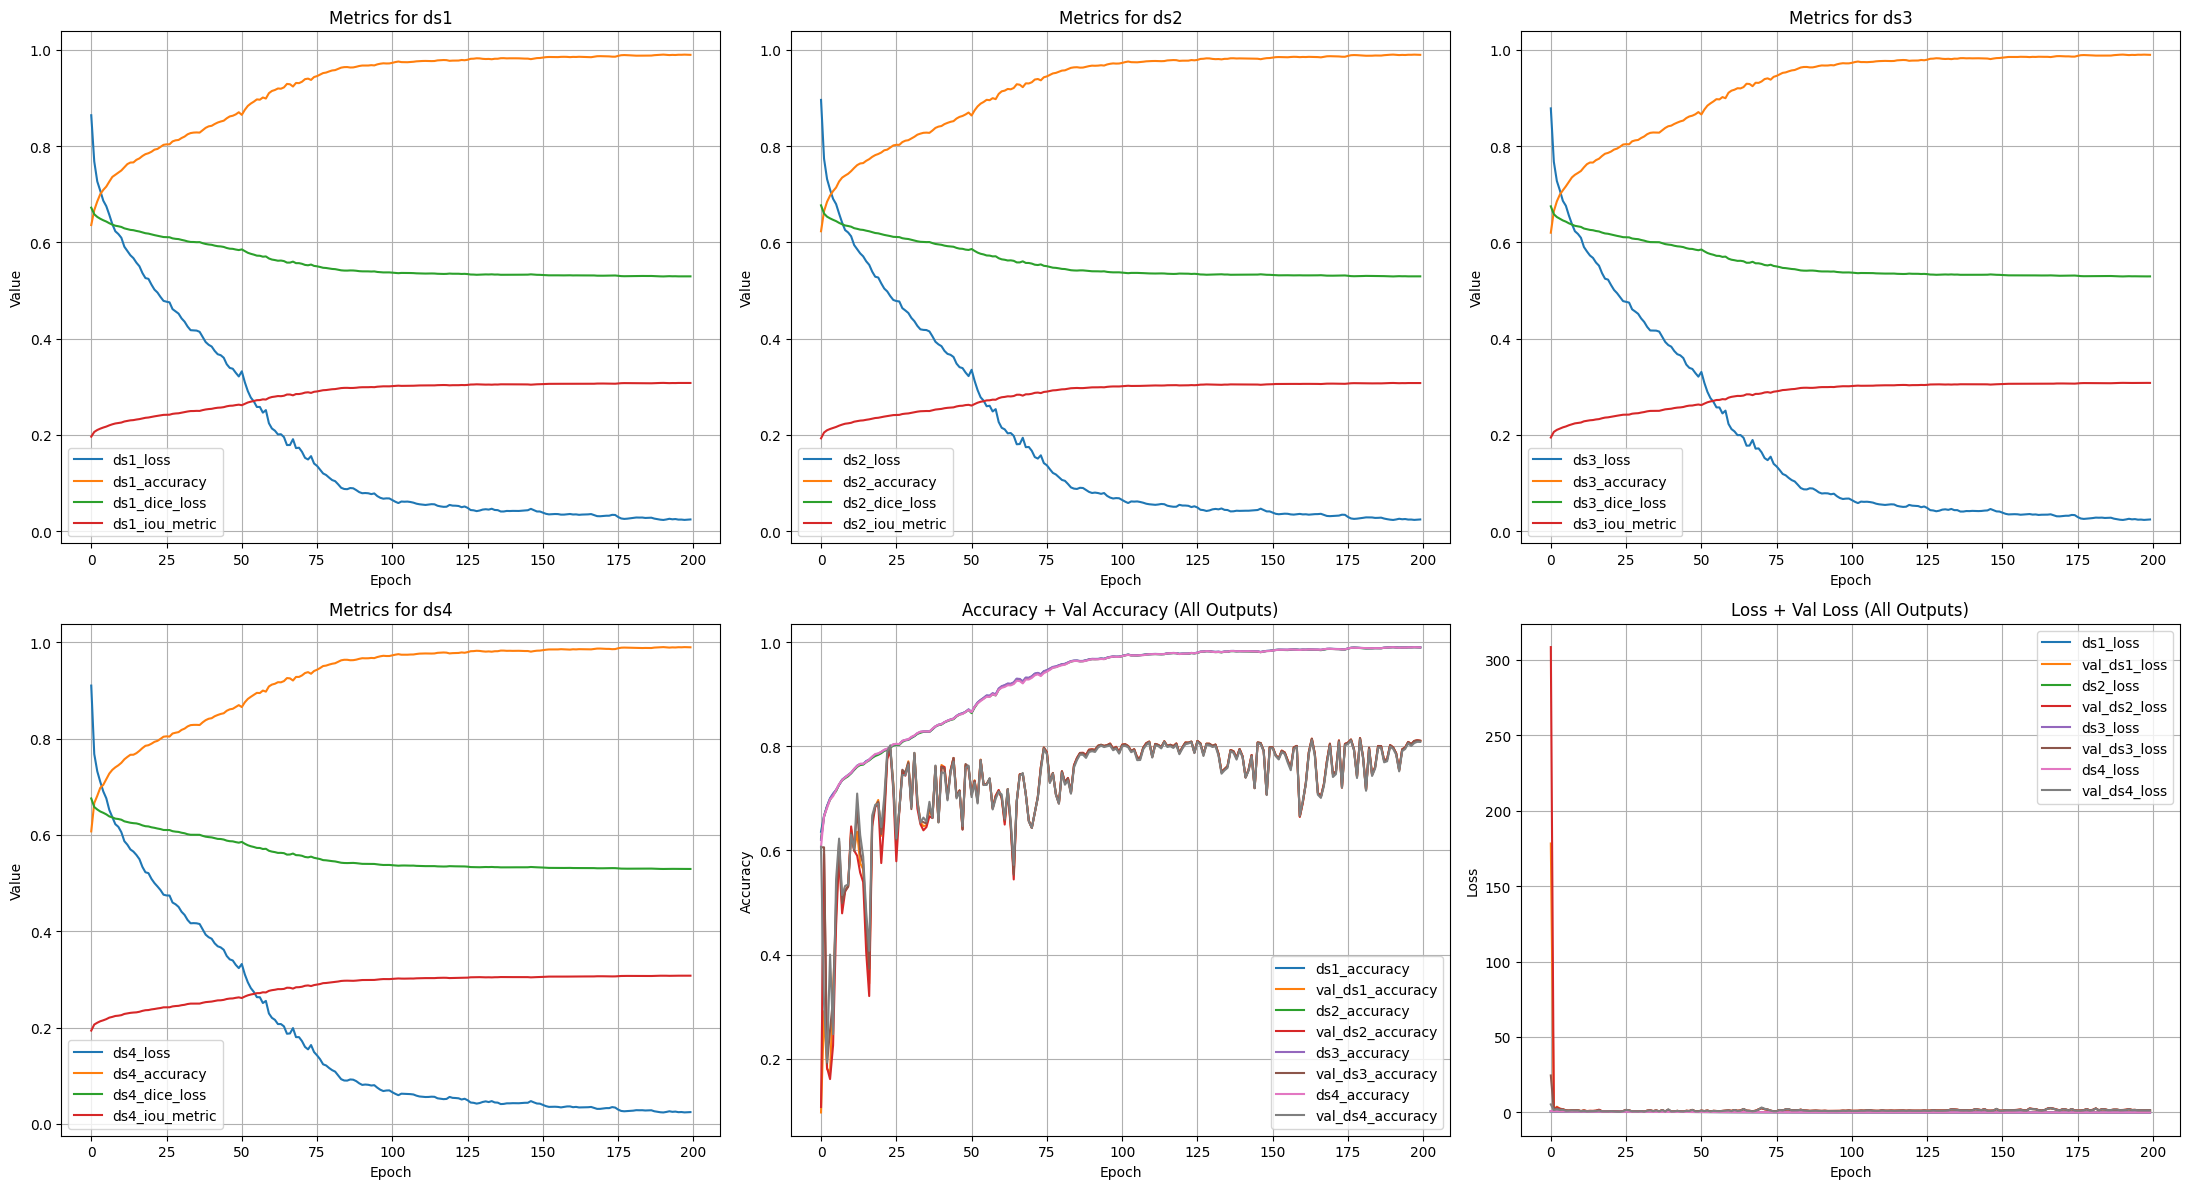

In [220]:
his = history.history

plt.figure(figsize=(22, 12))

# -------------------------------------------------------
# Plot 1: Metrics for ds1
# -------------------------------------------------------
plt.subplot(2, 3, 1)
plt.plot(his["ds1_loss"], label="ds1_loss")
plt.plot(his["ds1_accuracy"], label="ds1_accuracy")
plt.plot(his["ds1_dice_loss"], label="ds1_dice_loss")
plt.plot(his["ds1_iou_metric"], label="ds1_iou_metric")
plt.title("Metrics for ds1")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid()

# -------------------------------------------------------
# Plot 2: Metrics for ds2
# -------------------------------------------------------
plt.subplot(2, 3, 2)
plt.plot(his["ds2_loss"], label="ds2_loss")
plt.plot(his["ds2_accuracy"], label="ds2_accuracy")
plt.plot(his["ds2_dice_loss"], label="ds2_dice_loss")
plt.plot(his["ds2_iou_metric"], label="ds2_iou_metric")
plt.title("Metrics for ds2")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid()

# -------------------------------------------------------
# Plot 3: Metrics for ds3
# -------------------------------------------------------
plt.subplot(2, 3, 3)
plt.plot(his["ds3_loss"], label="ds3_loss")
plt.plot(his["ds3_accuracy"], label="ds3_accuracy")
plt.plot(his["ds3_dice_loss"], label="ds3_dice_loss")
plt.plot(his["ds3_iou_metric"], label="ds3_iou_metric")
plt.title("Metrics for ds3")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid()

# -------------------------------------------------------
# Plot 4: Metrics for ds4
# -------------------------------------------------------
plt.subplot(2, 3, 4)
plt.plot(his["ds4_loss"], label="ds4_loss")
plt.plot(his["ds4_accuracy"], label="ds4_accuracy")
plt.plot(his["ds4_dice_loss"], label="ds4_dice_loss")
plt.plot(his["ds4_iou_metric"], label="ds4_iou_metric")
plt.title("Metrics for ds4")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.legend()
plt.grid()

# -------------------------------------------------------
# Plot 5: All accuracies + val accuracies
# -------------------------------------------------------
plt.subplot(2, 3, 5)
for ds in ["ds1", "ds2", "ds3", "ds4"]:
    plt.plot(his[f"{ds}_accuracy"], label=f"{ds}_accuracy")
    plt.plot(his[f"val_{ds}_accuracy"], label=f"val_{ds}_accuracy")

plt.title("Accuracy + Val Accuracy (All Outputs)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# -------------------------------------------------------
# Plot 6: All losses + val losses
# -------------------------------------------------------
plt.subplot(2, 3, 6)
for ds in ["ds1", "ds2", "ds3", "ds4"]:
    plt.plot(his[f"{ds}_loss"], label=f"{ds}_loss")
    plt.plot(his[f"val_{ds}_loss"], label=f"val_{ds}_loss")

plt.title("Loss + Val Loss (All Outputs)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()


## Testing

In [221]:
results = model.evaluate(transformed_test_data)
print("Test metrics:", results)


14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 734ms/step - ds1_accuracy: 0.8211 - ds1_dice_loss: 0.5794 - ds1_iou_metric: 0.2663 - ds1_loss: 1.3672 - ds2_accuracy: 0.8212 - ds2_dice_loss: 0.5794 - ds2_iou_metric: 0.2663 - ds2_loss: 1.4304 - ds3_accuracy: 0.8211 - ds3_dice_loss: 0.5794 - ds3_iou_metric: 0.2663 - ds3_loss: 1.3554 - ds4_accuracy: 0.8188 - ds4_dice_loss: 0.5803 - ds4_iou_metric: 0.2656 - ds4_loss: 1.3637 - loss: 5.5178
Test metrics: [5.266064167022705, 1.3030864000320435, 1.3644649982452393, 1.2900351285934448, 1.3003758192062378, 0.8251869082450867, 0.57847660779953, 0.2670716941356659, 0.8252972960472107, 0.5784332156181335, 0.2671066224575043, 0.8252514600753784, 0.5784372687339783, 0.2671033442020416, 0.8227490782737732, 0.5794458389282227, 0.26629382371902466]


## Testing with 1 image

In [222]:
TEST_IMAGE = f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_109.png"
TEST_MASK = f"{DRIVE_EXT}/LabelStudioToMask_FINAL/masks/RVG_109_mask.png"

In [223]:
img = load_image(TEST_IMAGE)   # applies padding/resize etc.
img = tf.expand_dims(img, axis=0)  # shape: (1, H, W, 1)

preds = model.predict(img) #preds is a list

label_maps = []
for pred in preds:
  label_map = tf.argmax(pred, axis=-1)
  label_map = label_map[0]

  label_maps.append(label_map)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [224]:
gt_mask = load_mask(TEST_MASK)
gt_mask = tf.squeeze(gt_mask).numpy()


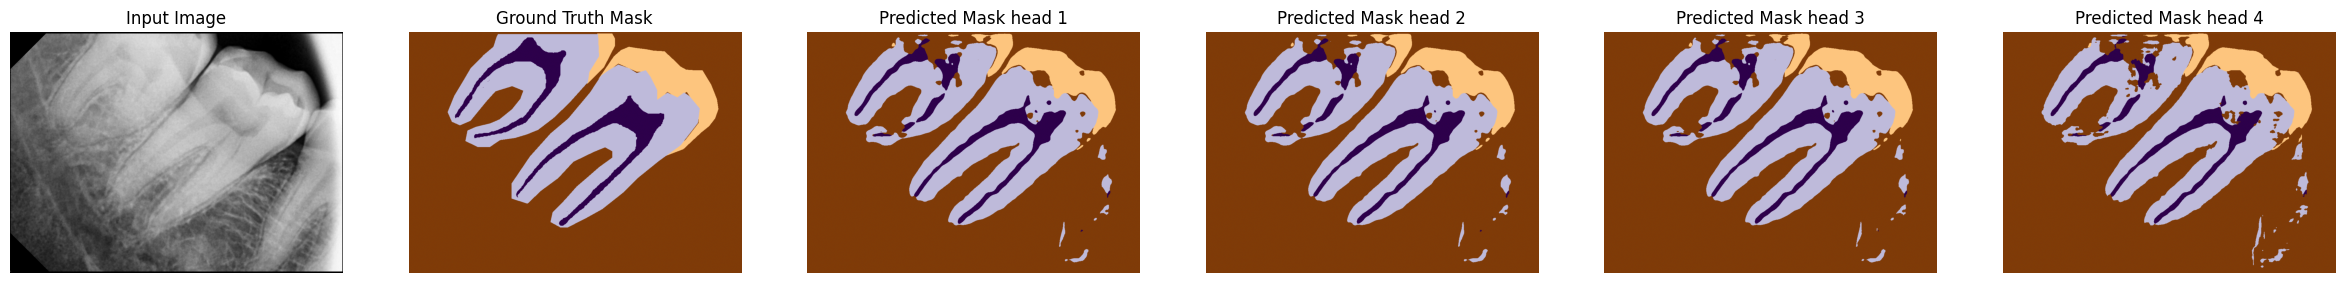

In [225]:
import matplotlib.pyplot as plt
HEADS = 4
SIZE = HEADS + 2
plt.figure(figsize=(30,8))

plt.subplot(1,SIZE,1)
plt.title("Input Image")
plt.imshow(tf.squeeze(img[0]), cmap='gray')
plt.axis('off')

plt.subplot(1,SIZE,2)
plt.title("Ground Truth Mask")
plt.imshow(gt_mask, cmap='PuOr')
plt.axis('off')

plt.subplot(1,SIZE,3)
plt.title("Predicted Mask head 1")
plt.imshow(label_maps[0], cmap='PuOr')
plt.axis('off')

plt.subplot(1,SIZE,4)
plt.title("Predicted Mask head 2")
plt.imshow(label_maps[1], cmap='PuOr')
plt.axis('off')

plt.subplot(1,SIZE,5)
plt.title("Predicted Mask head 3")
plt.imshow(label_maps[2], cmap='PuOr')
plt.axis('off')

plt.subplot(1,SIZE,6)
plt.title("Predicted Mask head 4")
plt.imshow(label_maps[3], cmap='PuOr')
plt.axis('off')

plt.savefig('/kaggle/working.')
plt.show()


## Trying with 10 images

In [226]:
TEST_IMAGES = [
    f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_101.png",
    f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_102.png",
    f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_103.png",
    f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_104.png",
    f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_105.png",
    f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_106.png",
    f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_107.png",
    f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_108.png",
    f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_109.png",
    f"{DRIVE_EXT}/LabelStudioToMask_FINAL/images/RVG_110.png",
]

In [227]:
def predict_all_heads(model, image_path, mask_path):
    img = load_image(image_path)
    img_batch = tf.expand_dims(img, axis=0)

    preds = model.predict(img_batch)

    label_maps = [tf.argmax(p, axis=-1)[0] for p in preds]
    gt_mask = load_mask(mask_path)
    gt_mask = tf.squeeze(gt_mask)

    return img, gt_mask, label_maps

def plot_row(img, gt_mask, label_maps, row_idx, total_rows):
    cols = 6  # Input + GT + 4 heads

    plt.subplot(total_rows, cols, row_idx * cols + 1)
    plt.imshow(tf.squeeze(img), cmap="gray")
    plt.title("Image")
    plt.axis("off")

    plt.subplot(total_rows, cols, row_idx * cols + 2)
    plt.imshow(gt_mask, cmap="PuOr")
    plt.title("GT")
    plt.axis("off")

    for i in range(4):   # 4 heads
        plt.subplot(total_rows, cols, row_idx * cols + 3 + i)
        plt.imshow(label_maps[i], cmap="PuOr")
        plt.title(f"Head {i+1}")
        plt.axis("off")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


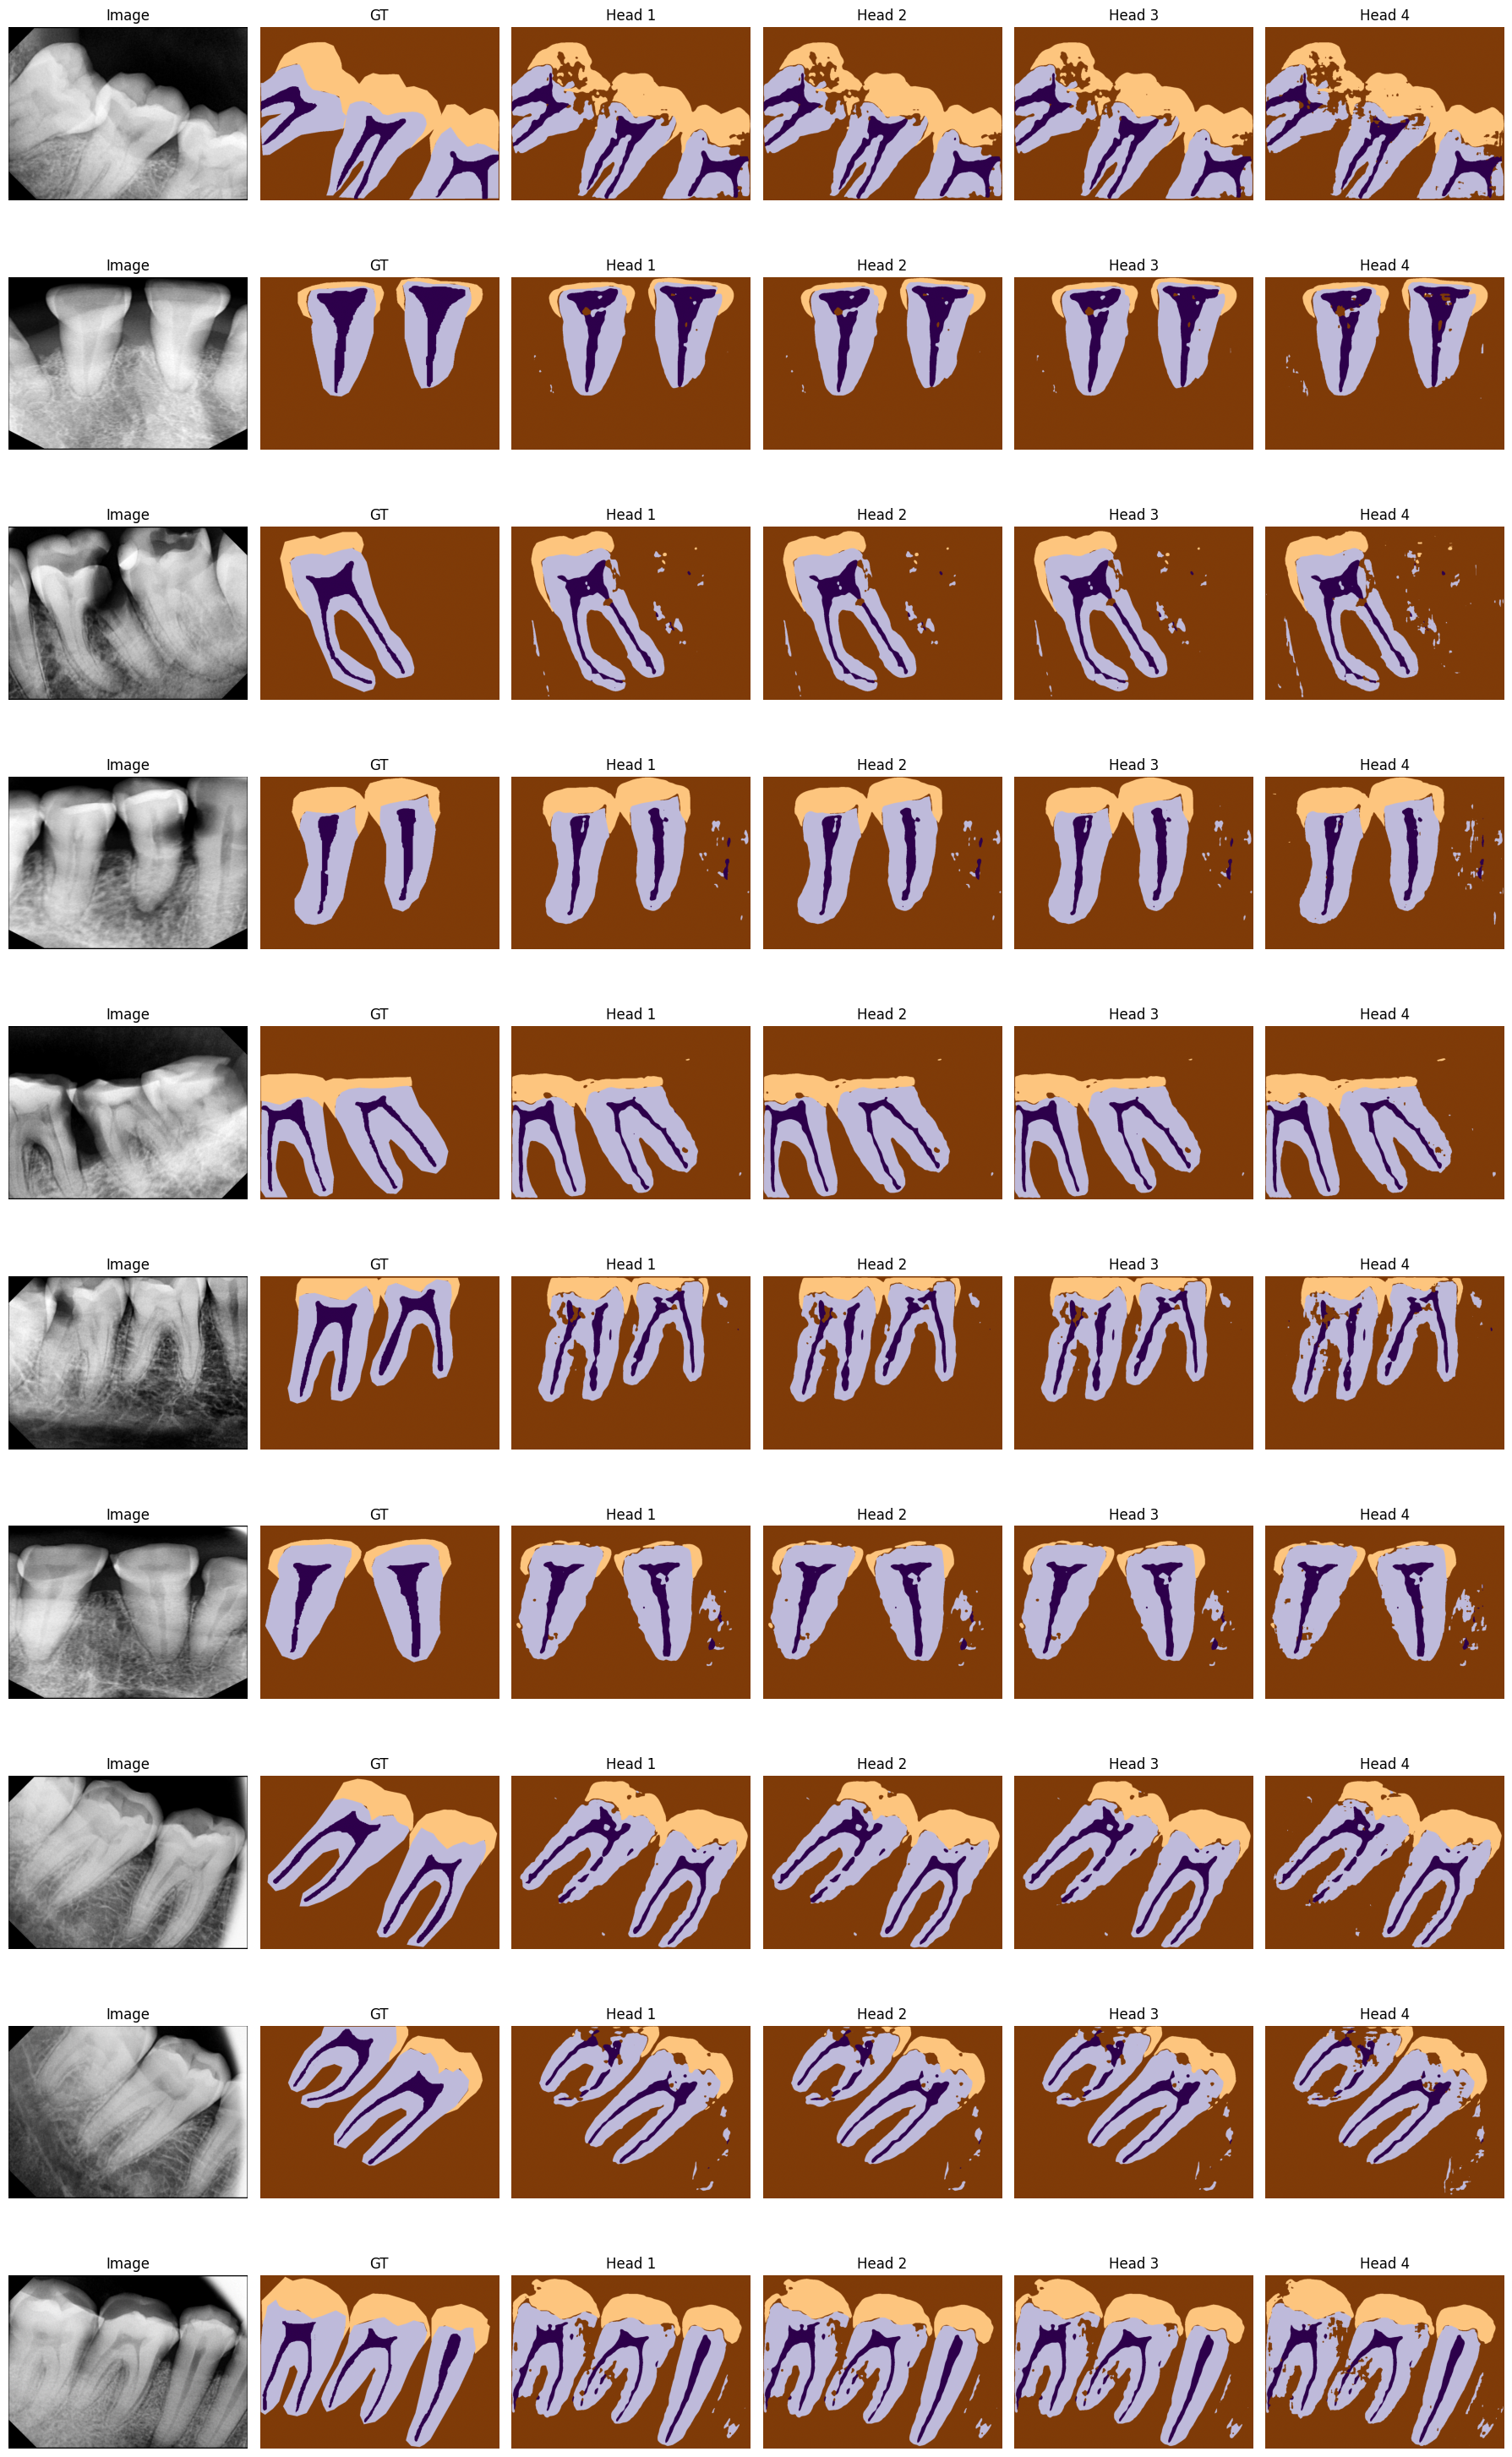

In [229]:
num_imgs = len(TEST_IMAGES)
cols = 6
plt.figure(figsize=(cols * 3, num_imgs * 3))

for idx, img_path in enumerate(TEST_IMAGES):
    base = img_path.split("/")[-1].replace(".png", "")
    mask_path = f"{DRIVE_EXT}/LabelStudioToMask_FINAL/masks/{base}_mask.png"

    # Predict
    img, gt_mask, label_maps = predict_all_heads(model, img_path, mask_path)

    # Plot in grid
    plot_row(img, gt_mask, label_maps, idx, num_imgs)

plt.tight_layout()
plt.savefig('U-net_Model v7 attention + custom losses + callbacks + plusplus + large dataset + overlapping patches + deep supervision preds 10.png')
plt.show()